# Notebook 2 — Basic GANs

**Phase 2** deliverable. Learning objectives:
- Vanilla GAN architecture
- DCGAN with best practices
- Conditional GAN for controlled generation
- Detecting & addressing mode collapse
- Wasserstein GAN for training stability

Complete the TODOs in `models/gans/` and `training/losses.py` (adversarial,
WGAN, and gradient-penalty losses) before running the training cells. Run
`pytest -m gan -v` to check your progress.


In [7]:
%matplotlib inline

import sys
from pathlib import Path

# Make `generative_art_studio` importable without `pip install -e .`
# REPO_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() else Path.cwd()
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import torch
from generative_art_studio.utils import set_seed, plot_image_grid
from generative_art_studio.config import DEVICE

set_seed(42)
print(f"Using device: {DEVICE}")


Using device: cuda


In [8]:
from generative_art_studio.data import SyntheticImageDataset, get_dataloader

dataset = SyntheticImageDataset(num_samples=256, image_size=64, num_classes=2)
dataloader = get_dataloader(dataset, batch_size=32)


## 1. Vanilla GAN (fully-connected) — reference architecture

In [9]:
from generative_art_studio.models.gans import VanillaGenerator, VanillaDiscriminator
from generative_art_studio.training.train_gan import train_gan
from torch.optim import Adam

latent_dim = 64
generator = VanillaGenerator(latent_dim=latent_dim).to(DEVICE)
discriminator = VanillaDiscriminator().to(DEVICE)

g_opt = Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_opt = Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

history = train_gan(generator, discriminator, dataloader, g_opt, d_opt, latent_dim, device=DEVICE, epochs=3)


GAN epoch 1/3:   0%|          | 0/8 [00:00<?, ?it/s]

GAN epoch 2/3:   0%|          | 0/8 [00:00<?, ?it/s]

GAN epoch 3/3:   0%|          | 0/8 [00:00<?, ?it/s]

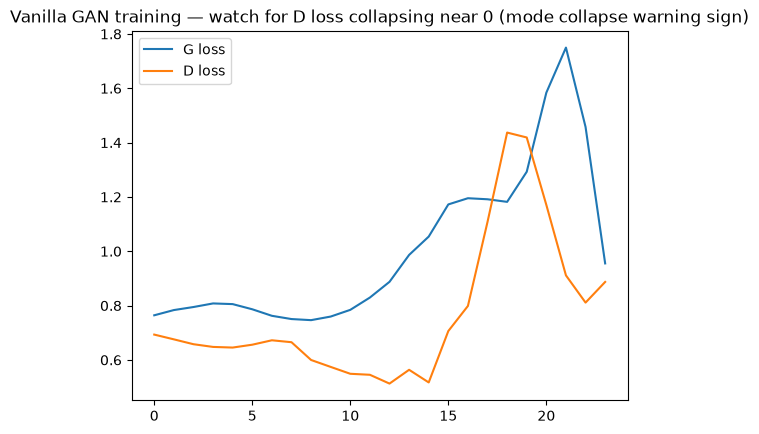

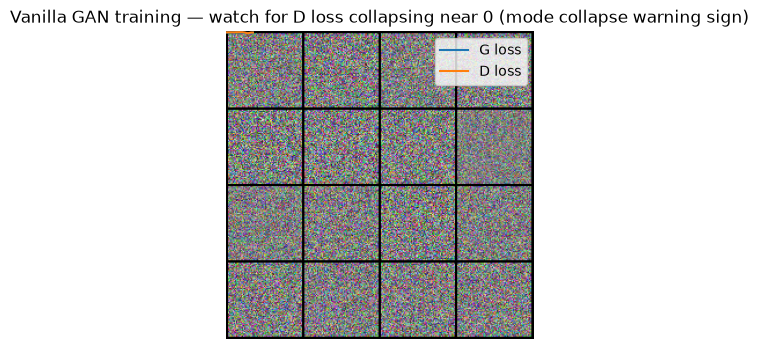

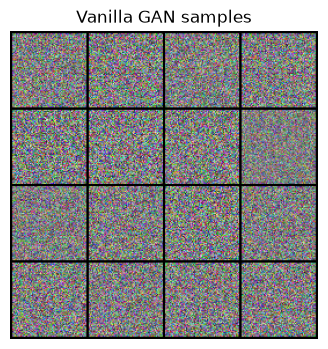

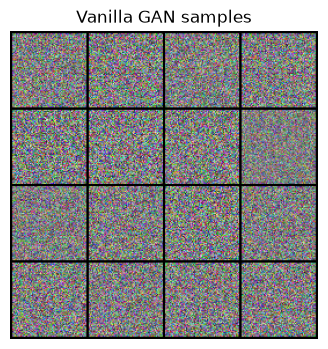

In [10]:
import matplotlib.pyplot as plt
plt.plot(history.g_loss, label="G loss")
plt.plot(history.d_loss, label="D loss")
plt.legend(); plt.title("Vanilla GAN training — watch for D loss collapsing near 0 (mode collapse warning sign)")
plt.show()

from generative_art_studio.utils.latent_space import sample_latent
z = sample_latent(16, latent_dim, DEVICE)
samples = generator(z)
plot_image_grid(samples.detach().cpu(), nrow=4, title="Vanilla GAN samples")


## 2. DCGAN

Implement `DCGANGenerator`/`DCGANDiscriminator` in `models/gans/dcgan.py`,
then repeat the training loop above with these models (remember to call
`.apply(weights_init_dcgan)` right after construction) and `latent_dim=100`.


GAN epoch 1/3:   0%|          | 0/8 [00:00<?, ?it/s]

GAN epoch 2/3:   0%|          | 0/8 [00:00<?, ?it/s]

GAN epoch 3/3:   0%|          | 0/8 [00:00<?, ?it/s]

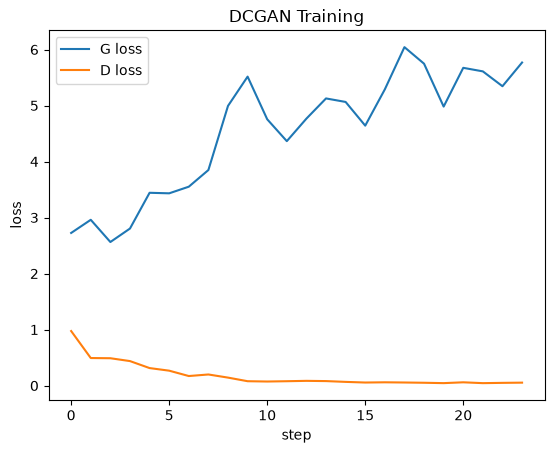

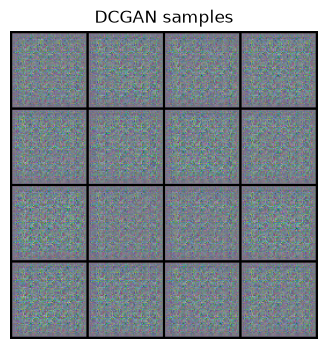

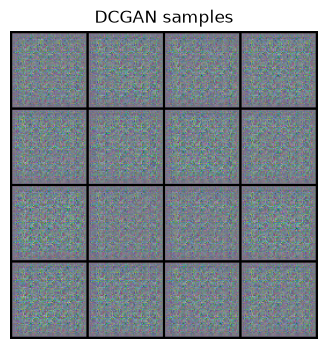

In [11]:
from generative_art_studio.models.gans import DCGANGenerator, DCGANDiscriminator, weights_init_dcgan

dc_latent_dim = 100
dc_generator = DCGANGenerator(latent_dim=dc_latent_dim, feature_maps=32).to(DEVICE)
dc_discriminator = DCGANDiscriminator(feature_maps=32).to(DEVICE)
dc_generator.apply(weights_init_dcgan)
dc_discriminator.apply(weights_init_dcgan)

# TODO: train dc_generator/dc_discriminator the same way as the vanilla GAN above,
# then visualize samples and compare training-curve stability.
dc_g_opt = Adam(
    dc_generator.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

dc_d_opt = Adam(
    dc_discriminator.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

dc_history = train_gan(
    dc_generator,
    dc_discriminator,
    dataloader,
    dc_g_opt,
    dc_d_opt,
    dc_latent_dim,
    device=DEVICE,
    epochs=3,
)

plt.figure()
plt.plot(dc_history.g_loss, label="G loss")
plt.plot(dc_history.d_loss, label="D loss")
plt.legend()
plt.title("DCGAN Training")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

dc_z = sample_latent(16, dc_latent_dim, DEVICE)

with torch.no_grad():
    dc_samples = dc_generator(dc_z)

plot_image_grid(
    dc_samples.cpu(),
    nrow=4,
    title="DCGAN samples"
)

## 3. Conditional GAN

Implement `ConditionalGenerator`/`ConditionalDiscriminator` in
`models/gans/conditional_gan.py`, then generate samples per class label to
demonstrate controlled generation.


In [12]:
from generative_art_studio.models.gans import ConditionalGenerator, ConditionalDiscriminator

cgan_gen = ConditionalGenerator(latent_dim=64, num_classes=2).to(DEVICE)

# TODO: train, then compare generator output for label=0 vs label=1 with the same z
# z = sample_latent(8, 64, DEVICE)
# samples_label0 = cgan_gen(z, torch.zeros(8, dtype=torch.long, device=DEVICE))
# samples_label1 = cgan_gen(z, torch.ones(8, dtype=torch.long, device=DEVICE))
cgan_disc = ConditionalDiscriminator(num_classes=2).to(DEVICE)

cgan_g_opt = Adam(
    cgan_gen.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

cgan_d_opt = Adam(
    cgan_disc.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

criterion = torch.nn.BCELoss()

cgan_g_losses = []
cgan_d_losses = []

for epoch in range(3):
    for real_images, labels in dataloader:
        real_images = real_images.to(DEVICE)
        labels = labels.to(DEVICE)

        batch_size = real_images.size(0)

        real_targets = torch.ones(batch_size, 1, device=DEVICE)
        fake_targets = torch.zeros(batch_size, 1, device=DEVICE)

        # ---------------------
        # Train Discriminator
        # ---------------------
        cgan_d_opt.zero_grad()

        real_scores = cgan_disc(real_images, labels)
        d_real_loss = criterion(real_scores, real_targets)

        z = sample_latent(batch_size, 64, DEVICE)
        fake_images = cgan_gen(z, labels)

        fake_scores = cgan_disc(fake_images.detach(), labels)
        d_fake_loss = criterion(fake_scores, fake_targets)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        cgan_d_opt.step()

        # -----------------
        # Train Generator
        # -----------------
        cgan_g_opt.zero_grad()

        z = sample_latent(batch_size, 64, DEVICE)
        fake_images = cgan_gen(z, labels)

        fake_scores = cgan_disc(fake_images, labels)

        g_loss = criterion(fake_scores, real_targets)
        g_loss.backward()
        cgan_g_opt.step()

        cgan_d_losses.append(d_loss.item())
        cgan_g_losses.append(g_loss.item())

    print(
        f"Epoch {epoch + 1}/3 | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch 1/3 | D Loss: 1.3224 | G Loss: 0.7782
Epoch 2/3 | D Loss: 1.5337 | G Loss: 1.1518
Epoch 3/3 | D Loss: 1.7245 | G Loss: 1.0960


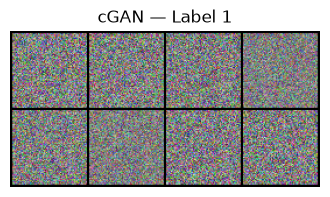

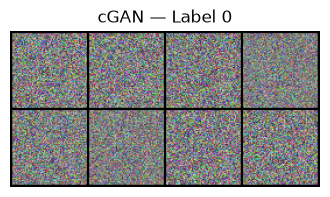

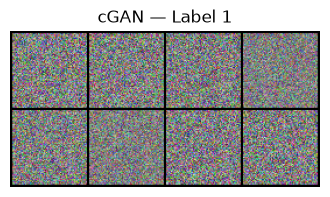

In [13]:
# perform the controlled generation

cgan_gen.eval()

z = sample_latent(8, 64, DEVICE)

labels_0 = torch.zeros(
    8,
    dtype=torch.long,
    device=DEVICE
)

labels_1 = torch.ones(
    8,
    dtype=torch.long,
    device=DEVICE
)

with torch.no_grad():
    samples_label0 = cgan_gen(z, labels_0)
    samples_label1 = cgan_gen(z, labels_1)

plot_image_grid(
    samples_label0.cpu(),
    nrow=4,
    title="cGAN — Label 0"
)

plot_image_grid(
    samples_label1.cpu(),
    nrow=4,
    title="cGAN — Label 1"
)

## 4. Wasserstein GAN (WGAN-GP)

Implement `WGANCritic` (`models/gans/wgan.py`) and `wgan_critic_loss` /
`wgan_generator_loss` / `gradient_penalty` (`training/losses.py`), then
write your own critic/generator training loop below — unlike the BCE GAN,
WGAN trains the critic `N_CRITIC` steps per generator step (see
`config.N_CRITIC`).


In [14]:
from generative_art_studio.models.gans import WGANCritic
from generative_art_studio.training.losses import wgan_critic_loss, wgan_generator_loss, gradient_penalty
from generative_art_studio import config

wgan_gen = DCGANGenerator(latent_dim=100, feature_maps=32).to(DEVICE)  # generator arch is unchanged
critic = WGANCritic(feature_maps=32).to(DEVICE)

# TODO: implement the WGAN-GP training loop:
#   for N_CRITIC steps: update critic using wgan_critic_loss + WGAN_GP_LAMBDA * gradient_penalty
#   then: one generator update using wgan_generator_loss
# Compare training-curve smoothness against the vanilla/DCGAN BCE-based runs above.
wgan_g_opt = Adam(
    wgan_gen.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

wgan_c_opt = Adam(
    critic.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

wgan_g_losses = []
wgan_c_losses = []
wgan_gp_losses = []

n_critic = config.N_CRITIC
gp_lambda = config.WGAN_GP_LAMBDA

data_iter = iter(dataloader)

for step in range(3 * len(dataloader)):
    # -----------------
    # Train Critic
    # -----------------
    for _ in range(n_critic):

        try:
            real_images, _ = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            real_images, _ = next(data_iter)

        real_images = real_images.to(DEVICE)
        batch_size = real_images.size(0)

        wgan_c_opt.zero_grad()

        z = sample_latent(batch_size, 100, DEVICE)
        fake_images = wgan_gen(z)

        real_score = critic(real_images)
        fake_score = critic(fake_images.detach())

        critic_loss = wgan_critic_loss(
            real_score,
            fake_score
        )

        gp = gradient_penalty(
            critic,
            real_images,
            fake_images.detach(),
            device=DEVICE,
        )

        total_critic_loss = critic_loss + gp_lambda * gp

        total_critic_loss.backward()
        wgan_c_opt.step()

        wgan_c_losses.append(total_critic_loss.item())
        wgan_gp_losses.append(gp.item())

    # -----------------
    # Train Generator
    # -----------------
    wgan_g_opt.zero_grad()

    z = sample_latent(batch_size, 100, DEVICE)
    fake_images = wgan_gen(z)

    fake_score = critic(fake_images)

    generator_loss = wgan_generator_loss(fake_score)

    generator_loss.backward()
    wgan_g_opt.step()

    wgan_g_losses.append(generator_loss.item())

print("WGAN-GP training complete.")

WGAN-GP training complete.


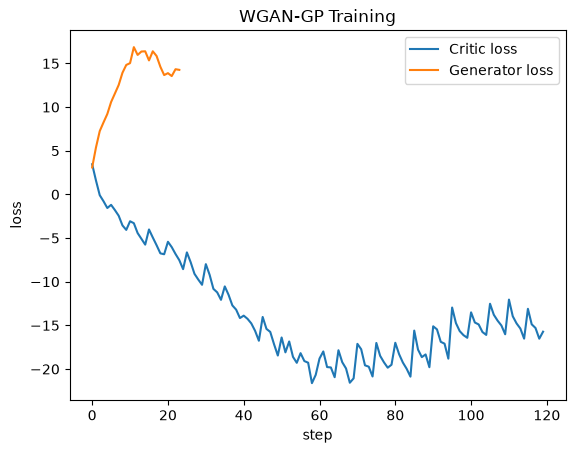

In [15]:
# Visualize training curves
plt.figure()
plt.plot(wgan_c_losses, label="Critic loss")
plt.plot(wgan_g_losses, label="Generator loss")
plt.legend()
plt.xlabel("step")
plt.ylabel("loss")
plt.title("WGAN-GP Training")
plt.show()

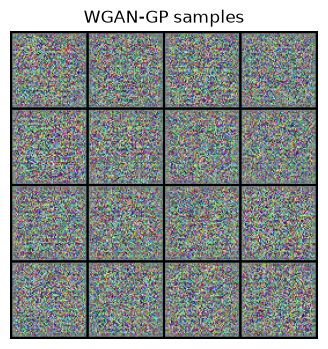

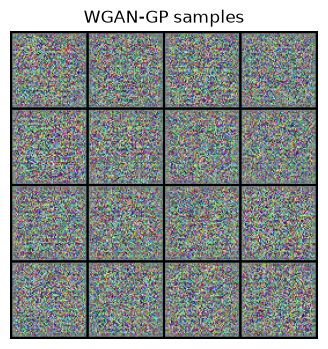

In [16]:
# generate samples:
wgan_gen.eval()

z = sample_latent(16, 100, DEVICE)

with torch.no_grad():
    wgan_samples = wgan_gen(z)

plot_image_grid(
    wgan_samples.cpu(),
    nrow=4,
    title="WGAN-GP samples"
)

## Reflection (for your Technical Report)

- Did you observe **mode collapse** in any model (e.g. all generated
  samples looking nearly identical)? Show a sample grid as evidence.
- Compare G/D loss curve *shape* across vanilla GAN, DCGAN, and WGAN — which
  was most stable, and why (tie back to what each loss function optimizes)?
- What did conditioning on class label change about controllability?


### 1. Mode Collapse

I did not observe clear evidence of severe mode collapse in the Vanilla GAN, DCGAN, or WGAN-GP sample grids. The generated samples were not identical to one another and showed variation across the grid. However, the images remained highly noisy and did not yet resemble meaningful visual structures. Therefore, the main limitation in these short training runs appears to be **poor image quality and insufficient convergence rather than obvious mode collapse**.

The Vanilla GAN showed fluctuating generator and discriminator losses, while the DCGAN discriminator loss quickly approached zero. This suggests that the discriminator became very effective at distinguishing real from generated samples, which can make generator training more difficult. Because the experiments used a small synthetic dataset and only a few epochs, longer training on a real image dataset such as CelebA would be needed to make a stronger conclusion about mode collapse.

### 2. Comparison of GAN Loss Curves

The three models showed noticeably different loss behaviors.

* **Vanilla GAN:** The generator and discriminator losses fluctuated throughout training. The discriminator loss remained above zero but varied considerably, while the generator loss increased and later decreased. This indicates the typical adversarial competition between the generator and discriminator and relatively unstable training.
* **DCGAN:** The discriminator loss rapidly decreased toward zero while the generator loss increased substantially. This indicates that the discriminator became much stronger than the generator during this short training run. Although the DCGAN architecture follows convolutional best practices, the training curves suggest that the adversarial game was not yet balanced.
* **WGAN-GP:** The critic and generator losses followed a different pattern, with the critic loss becoming increasingly negative and the generator loss increasing before fluctuating. Unlike the BCE-based GANs, the critic does not output a probability and instead optimizes the Wasserstein objective. The gradient penalty also encourages the critic to satisfy the required Lipschitz constraint, providing more useful and stable gradients to the generator.

Overall, **WGAN-GP appeared to provide the most meaningful training behavior from a stability perspective**, although its curves still fluctuated. The Wasserstein objective measures the difference between the real and generated distributions through critic scores rather than relying on binary classification with BCE. This can provide more informative gradients when the generated and real distributions are initially far apart.

### 3. Effect of Conditional Generation

The cGAN introduced class information into both the generator and discriminator. The generator received the latent vector together with an embedded class label, while the discriminator evaluated both the image and its corresponding label.

Using the **same latent vector** with label 0 and label 1 allowed us to test whether changing only the class condition affected the generated output. In these experiments, the two sample grids remained visually similar and highly noisy, so there was **not yet strong visual evidence of learned class-specific controllability**.

This is expected given the short three-epoch training run and the synthetic dataset. With longer training and a dataset containing clearly distinguishable classes, the conditioning mechanism should allow the same latent noise vector to produce different outputs according to the requested class. Thus, the cGAN architecture provides the mechanism for controlled generation, but the current experiment does not yet demonstrate strong class separation visually.
